In [2]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from pathlib import Path
import random

# Importer votre U-Net
import sys
sys.path.append('..')  # Pour importer depuis le dossier parent
from unet import UNet3D

# Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4070


### Dataset PyTorch personnalisé

In [3]:
class GrainDistanceDataset(Dataset):
    """
    Dataset pour paires (image, distance_map).
    Extrait des patches 3D aléatoires.
    """
    def __init__(self, image_files, distance_files, patch_size=64, num_patches_per_volume=10):
        """
        Args:
            image_files: Liste de chemins vers images synthétiques
            distance_files: Liste de chemins vers distance maps (même ordre)
            patch_size: Taille des patches 3D à extraire
            num_patches_per_volume: Nombre de patches par volume
        """
        self.image_files = image_files
        self.distance_files = distance_files
        self.patch_size = patch_size
        self.num_patches = num_patches_per_volume
        
        # Pré-charger tous les volumes (si assez de RAM)
        print("Chargement des volumes...")
        self.images = []
        self.distances = []
        
        for img_path, dist_path in zip(image_files, distance_files):
            # Charger image
            img = tifffile.imread(img_path).astype(np.float32)
            # Normaliser 0-1
            img = img / 65535.0 if img.max() > 1 else img
            self.images.append(img)
            
            # Charger distance
            dist = tifffile.imread(dist_path).astype(np.float32)
            dist = dist / 65535.0 if dist.max() > 1 else dist
            self.distances.append(dist)
        
        print(f"Chargé {len(self.images)} volumes")
    
    def __len__(self):
        return len(self.images) * self.num_patches
    
    def __getitem__(self, idx):
        # Déterminer quel volume
        volume_idx = idx // self.num_patches
        
        img = self.images[volume_idx]
        dist = self.distances[volume_idx]
        
        # Extraire patch aléatoire
        d, h, w = img.shape
        ps = self.patch_size
        
        # Positions aléatoires
        z = random.randint(0, d - ps)
        y = random.randint(0, h - ps)
        x = random.randint(0, w - ps)
        
        # Extraire patches
        img_patch = img[z:z+ps, y:y+ps, x:x+ps]
        dist_patch = dist[z:z+ps, y:y+ps, x:x+ps]
        
        # Convertir en tenseurs PyTorch (ajouter dimension channel)
        img_tensor = torch.from_numpy(img_patch[np.newaxis, ...])  # (1, D, H, W)
        dist_tensor = torch.from_numpy(dist_patch[np.newaxis, ...])  # (1, D, H, W)
        
        return img_tensor, dist_tensor

### Créer le dataset

In [4]:
# Trouver les fichiers
print(os.getcwd())

image_folder = os.getcwd() + "/dataset/default/"
distance_folder = os.getcwd() + "/dataset/ground_truth/"

# Lister les fichiers (assurer même ordre)
image_files = sorted([os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith('.tif')])
distance_files = []

for img_file in image_files:
    basename = os.path.basename(img_file).replace('.spheres_image_gaussian=08_noise=30.tif', '.spheres_ground_truth.tif')
    dist_file = os.path.join(distance_folder, basename)
    if os.path.exists(dist_file):
        distance_files.append(dist_file)
    else:
        print(f"Warning: {dist_file} not found")

print(f"Fichiers trouvés:")
print(f"  Images: {len(image_files)}")
print(f"  Distance maps: {len(distance_files)}")

# Créer dataset
if len(image_files) > 0 and len(distance_files) > 0:
    dataset = GrainDistanceDataset(
        image_files[:2],  # Commencer avec 2 volumes pour test
        distance_files[:2],
        patch_size=64,
        num_patches_per_volume=20  # 20 patches par volume
    )
    
    print(f"\nDataset créé: {len(dataset)} patches au total")
    
    # Test : afficher un exemple
    img_sample, dist_sample = dataset[0]
    print(f"  Shape input: {img_sample.shape}")
    print(f"  Shape target: {dist_sample.shape}")
else:
    print("\n⚠️ Pas de fichiers trouvés ! Vérifiez les chemins.")

/home/alex/PFEE/data_yukiko


FileNotFoundError: [Errno 2] No such file or directory: '/home/alex/PFEE/data_yukiko/dataset/default/'

### Visualiser des exemples

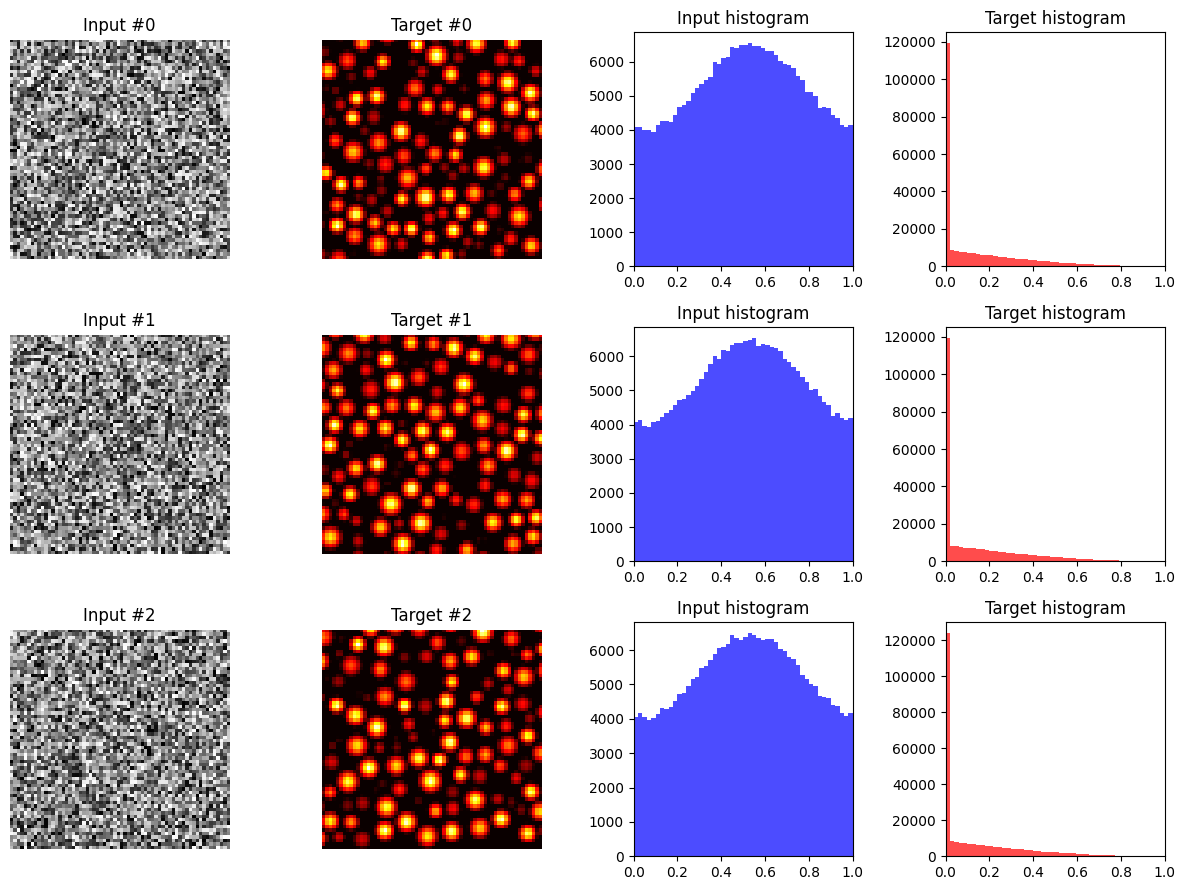

In [4]:
# Visualiser quelques paires
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i in range(3):
    img, dist = dataset[i]
    
    # Coupe au milieu
    mid = img.shape[1] // 2
    
    # Image
    axes[i, 0].imshow(img[0, mid], cmap='gray')
    axes[i, 0].set_title(f'Input #{i}')
    axes[i, 0].axis('off')
    
    # Distance
    axes[i, 1].imshow(dist[0, mid], cmap='hot')
    axes[i, 1].set_title(f'Target #{i}')
    axes[i, 1].axis('off')
    
    # Histogrammes
    axes[i, 2].hist(img.flatten().numpy(), bins=50, alpha=0.7, color='blue')
    axes[i, 2].set_title('Input histogram')
    axes[i, 2].set_xlim(0, 1)
    
    axes[i, 3].hist(dist.flatten().numpy(), bins=50, alpha=0.7, color='red')
    axes[i, 3].set_title('Target histogram')
    axes[i, 3].set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [5]:
class CombinedLoss(nn.Module):

    def __init__(self, alpha=0.7, beta=0.3):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.mse = nn.MSELoss()
    
    def gradient_loss(self, pred, target):
        grad_pred_z = pred[:, :, 1:, :, :] - pred[:, :, :-1, :, :]
        grad_target_z = target[:, :, 1:, :, :] - target[:, :, :-1, :, :]
        
        grad_pred_y = pred[:, :, :, 1:, :] - pred[:, :, :, :-1, :]
        grad_target_y = target[:, :, :, 1:, :] - target[:, :, :, :-1, :]
        
        grad_pred_x = pred[:, :, :, :, 1:] - pred[:, :, :, :, :-1]
        grad_target_x = target[:, :, :, :, 1:] - target[:, :, :, :, :-1]
        
        loss = (self.mse(grad_pred_z, grad_target_z) + 
                self.mse(grad_pred_y, grad_target_y) + 
                self.mse(grad_pred_x, grad_target_x)) / 3
        
        return loss
    
    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        grad_loss = self.gradient_loss(pred, target)
        return self.alpha * mse_loss + self.beta * grad_loss


def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
    
    return total_loss / len(dataloader)




criterion = CombinedLoss(alpha=0.7, beta=0.3)

## Créer le DataLoader

In [6]:
class GrainDistanceDatasetAugmented(Dataset):
    def __init__(self, image_files, distance_files, patch_size=64, 
                 num_patches_per_volume=50, augment=True):
        self.image_files = image_files
        self.distance_files = distance_files
        self.patch_size = patch_size
        self.num_patches = num_patches_per_volume
        self.augment = augment
        
        print("Chargement des volumes...")
        self.images = []
        self.distances = []
        
        for img_path, dist_path in zip(image_files, distance_files):
            img = tifffile.imread(img_path).astype(np.float32)
            img = img / 65535.0 if img.max() > 1 else img
            self.images.append(img)
            
            dist = tifffile.imread(dist_path).astype(np.float32)
            dist = dist / 65535.0 if dist.max() > 1 else dist
            self.distances.append(dist)
        
        print(f"Chargé {len(self.images)} volumes")
    
    def __len__(self):
        return len(self.images) * self.num_patches
    
    def __getitem__(self, idx):
        volume_idx = idx // self.num_patches
        
        img = self.images[volume_idx]
        dist = self.distances[volume_idx]
        
        d, h, w = img.shape
        ps = self.patch_size
        
        z = random.randint(0, d - ps)
        y = random.randint(0, h - ps)
        x = random.randint(0, w - ps)
        
        img_patch = img[z:z+ps, y:y+ps, x:x+ps]
        dist_patch = dist[z:z+ps, y:y+ps, x:x+ps]
        
        if self.augment and random.random() > 0.5:
            if random.random() > 0.5:
                img_patch = np.flip(img_patch, axis=0).copy()
                dist_patch = np.flip(dist_patch, axis=0).copy()
            if random.random() > 0.5:
                img_patch = np.flip(img_patch, axis=1).copy()
                dist_patch = np.flip(dist_patch, axis=1).copy()
            if random.random() > 0.5:
                img_patch = np.flip(img_patch, axis=2).copy()
                dist_patch = np.flip(dist_patch, axis=2).copy()
            
            k = random.randint(0, 3)
            if k > 0:
                img_patch = np.rot90(img_patch, k=k, axes=(1, 2)).copy()
                dist_patch = np.rot90(dist_patch, k=k, axes=(1, 2)).copy()
        
        img_tensor = torch.from_numpy(img_patch[np.newaxis, ...])
        dist_tensor = torch.from_numpy(dist_patch[np.newaxis, ...])
        
        return img_tensor, dist_tensor

full_dataset = GrainDistanceDatasetAugmented(
    image_files,
    distance_files,
    patch_size=64,
    num_patches_per_volume=100,
    augment=True
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size 

train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

Chargement des volumes...
Chargé 5 volumes


In [7]:
num_epochs = 250

model = UNet3D(in_channels=1, out_channels=1, init_features=48).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

In [8]:

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 0

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    print(f"  Train Loss: {train_loss:.6f}")
    print(f"  Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_unet_distance_f32.pth')
    
    if epoch > 0 and val_loss > best_val_loss * 1.1:
        if(patience == 10):
            break
        patience += 1
        continue
    patience = 0

Epoch 1/250


/home/max/PFEE/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:204: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  Train Loss: 0.075659
  Val Loss: 0.056645
Epoch 2/250
  Train Loss: 0.048326
  Val Loss: 0.044819
Epoch 3/250
  Train Loss: 0.040762
  Val Loss: 0.037881
Epoch 4/250
  Train Loss: 0.036803
  Val Loss: 0.035609
Epoch 5/250
  Train Loss: 0.034497
  Val Loss: 0.034378
Epoch 6/250
  Train Loss: 0.032989
  Val Loss: 0.032261
Epoch 7/250
  Train Loss: 0.031914
  Val Loss: 0.031177
Epoch 8/250
  Train Loss: 0.031025
  Val Loss: 0.030697
Epoch 9/250
  Train Loss: 0.030493
  Val Loss: 0.030439
Epoch 10/250
  Train Loss: 0.030044
  Val Loss: 0.030370
Epoch 11/250
  Train Loss: 0.029707
  Val Loss: 0.029225
Epoch 12/250
  Train Loss: 0.029248
  Val Loss: 0.029193
Epoch 13/250
  Train Loss: 0.028928
  Val Loss: 0.028658
Epoch 14/250
  Train Loss: 0.028108
  Val Loss: 0.028014
Epoch 15/250
  Train Loss: 0.028024
  Val Loss: 0.028298
Epoch 16/250
  Train Loss: 0.027389
  Val Loss: 0.027560
Epoch 17/250
  Train Loss: 0.026891
  Val Loss: 0.026504
Epoch 18/250
  Train Loss: 0.026178
  Val Loss: 0.02

KeyboardInterrupt: 

### Visualiser les courbes d'apprentissage

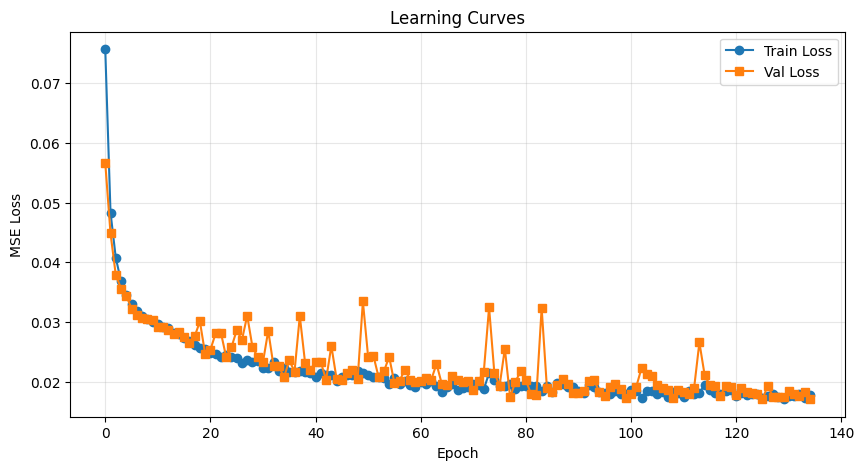

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Évaluer le modèle

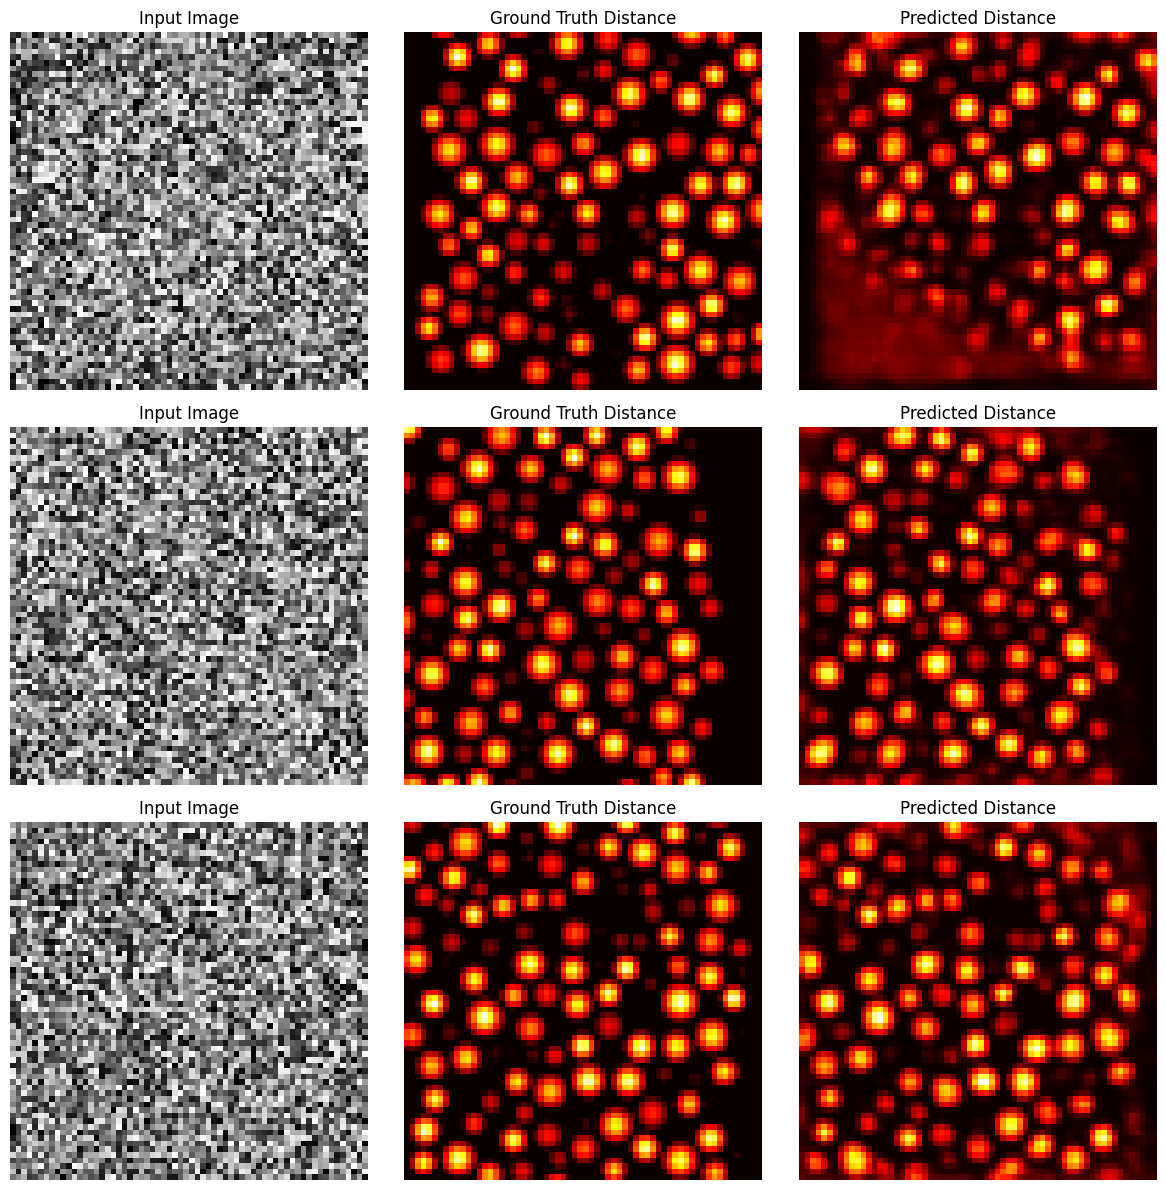

In [10]:
model.load_state_dict(torch.load('best_unet_distance_f32.pth'))
model.eval()

# Prédire sur quelques exemples
num_examples = 3
fig, axes = plt.subplots(num_examples, 3, figsize=(12, num_examples*4))

with torch.no_grad():
    for i in range(num_examples):
        # Prendre un exemple du dataset
        img, target = val_dataset[i]
        
        # Prédiction
        img_batch = img.unsqueeze(0).to(device)  # Ajouter batch dimension
        pred = model(img_batch).cpu().squeeze(0)  # Retirer batch dimension
        
        # Coupe au milieu
        mid = img.shape[1] // 2
        
        # Input
        axes[i, 0].imshow(img[0, mid], cmap='gray')
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')
        
        # Target
        axes[i, 1].imshow(target[0, mid], cmap='hot')
        axes[i, 1].set_title('Ground Truth Distance')
        axes[i, 1].axis('off')
        
        # Prediction
        axes[i, 2].imshow(pred[0, mid], cmap='hot')
        axes[i, 2].set_title('Predicted Distance')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## Appliquer sur une image complète

In [11]:
def predict_full_volume(model, image, patch_size=64, overlap=16, device='cpu'):
    """
    Prédire la distance map sur un volume complet avec sliding window.
    
    Args:
        model: U-Net entraîné
        image: Volume 3D (D, H, W)
        patch_size: Taille des patches
        overlap: Chevauchement entre patches
    """
    model.eval()
    
    d, h, w = image.shape
    stride = patch_size - overlap
    
    # Output et compteur pour averaging
    output = np.zeros_like(image, dtype=np.float32)
    count = np.zeros_like(image, dtype=np.float32)
    
    with torch.no_grad():
        # Sliding window
        for z in range(0, d - patch_size + 1, stride):
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):
                    # Extraire patch
                    patch = image[z:z+patch_size, y:y+patch_size, x:x+patch_size]
                    
                    # Prédire
                    patch_tensor = torch.from_numpy(patch[np.newaxis, np.newaxis, ...]).to(device)
                    pred = model(patch_tensor).cpu().numpy()[0, 0]
                    
                    # Accumuler
                    output[z:z+patch_size, y:y+patch_size, x:x+patch_size] += pred
                    count[z:z+patch_size, y:y+patch_size, x:x+patch_size] += 1
    
    # Moyenner les zones de chevauchement
    output = output / np.maximum(count, 1)
    
    return output


# Tester sur une image synthétique
test_image = tifffile.imread(image_files[0]).astype(np.float32) / 65535.0

print(f"Prédiction sur volume complet {test_image.shape}...")
print("(Cela peut prendre plusieurs minutes)")

predicted_distance = predict_full_volume(model, test_image, patch_size=64, overlap=16, device=device)

print(f"✓ Prédiction terminée")
print(f"  Output shape: {predicted_distance.shape}")
print(f"  Output range: [{predicted_distance.min():.3f}, {predicted_distance.max():.3f}]")

# Sauvegarder
output_file = "predicted_distance_map.tif"
tifffile.imwrite(output_file, (predicted_distance * 65535).astype(np.uint16))
print(f"  Sauvegardé: {output_file}")

Prédiction sur volume complet (122, 122, 122)...
(Cela peut prendre plusieurs minutes)
✓ Prédiction terminée
  Output shape: (122, 122, 122)
  Output range: [0.000, 0.918]
  Sauvegardé: predicted_distance_map.tif


## Appliquer Watershed sur la prédiction

In [12]:
from watershed_segmentation import watershed_segmentation

# Segmenter avec watershed
labels, num_grains, mask = watershed_segmentation(
    predicted_distance,
    min_distance=3,
    verbose=True
)

print(f"\n✓ Segmentation terminée: {num_grains} grains détectés")

# Comparer avec la vraie distance map
true_distance = tifffile.imread(distance_files[0]).astype(np.float32) / 65535.0
true_labels, true_num_grains, _ = watershed_segmentation(true_distance, min_distance=3, verbose=False)

print(f"\nComparaison:")
print(f"  Grains détectés (U-Net): {num_grains}")
print(f"  Grains réels (Ground Truth): {true_num_grains}")
print(f"  Précision: {num_grains / true_num_grains * 100:.1f}%")

Step 1: Extracting grain mask...
  Grain mask contains 1,404,928 voxels (77.37%)
Step 2: Detecting grain centers (local maxima)...
  Found 4047 local maxima (grain centers)
Step 3: Labeling grain centers...
  Created 4047 labeled markers
Step 4: Propagating labels with watershed...
  Watershed completed in 1.23s
Step 5: Applying final mask...
Segmentation complete!
  Total grains detected: 4047
  Total time: 1.23s

✓ Segmentation terminée: 4047 grains détectés

Comparaison:
  Grains détectés (U-Net): 4047
  Grains réels (Ground Truth): 5459
  Précision: 74.1%


## Visualiser les résultats

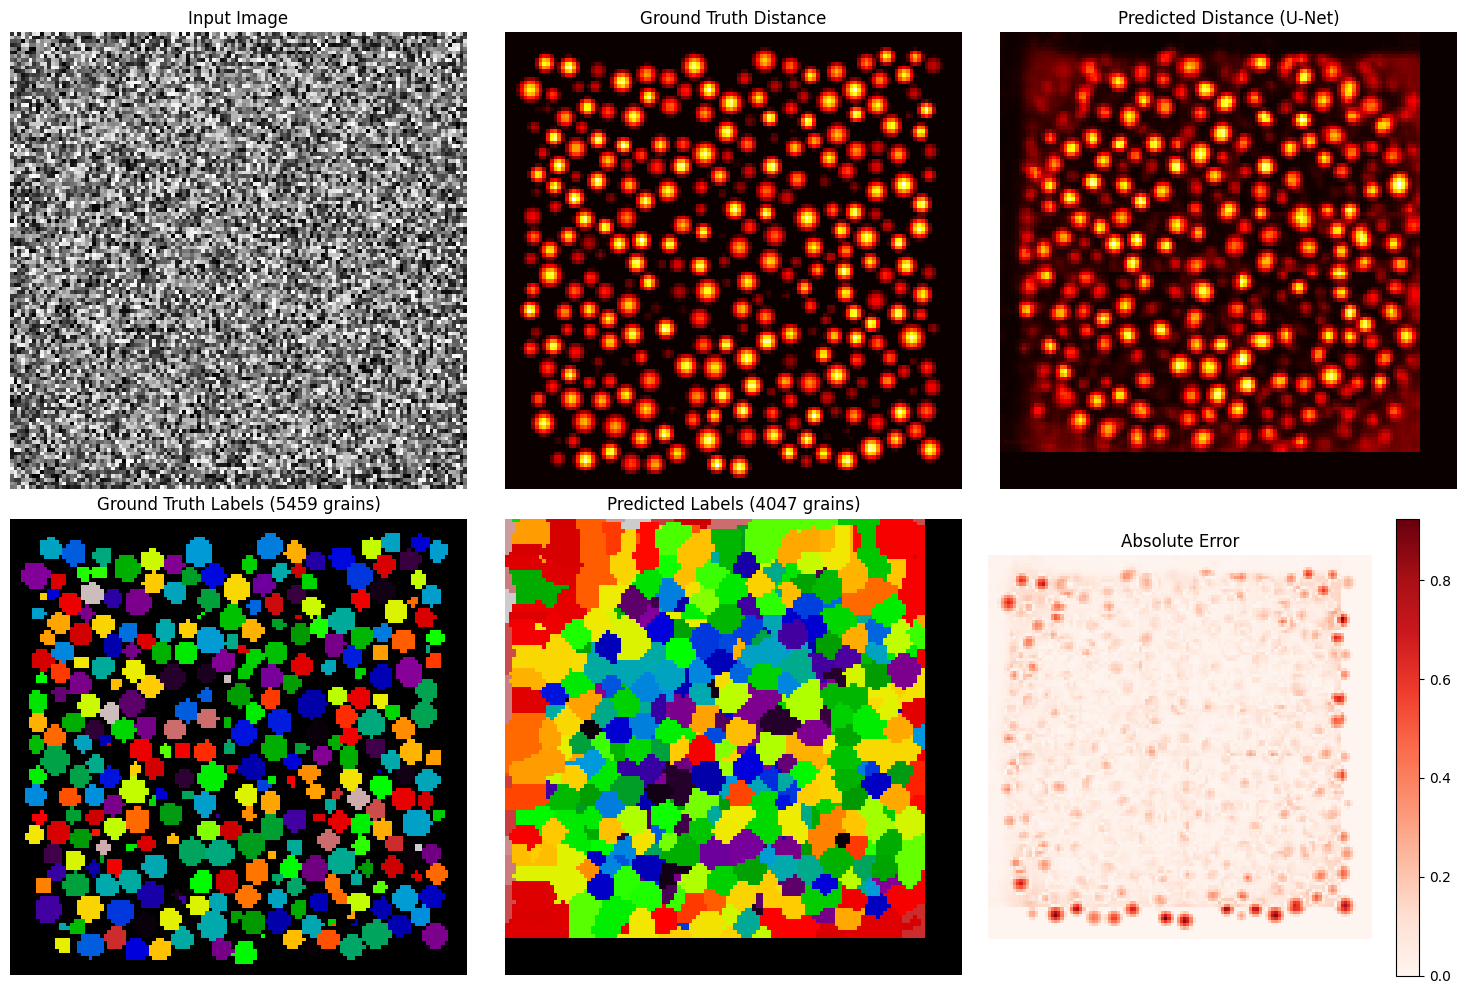


Mean Absolute Error: 0.062501


In [13]:
# Comparer prédiction vs ground truth
slice_idx = test_image.shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Input image
axes[0, 0].imshow(test_image[slice_idx], cmap='gray')
axes[0, 0].set_title('Input Image')
axes[0, 0].axis('off')

# True distance
axes[0, 1].imshow(true_distance[slice_idx], cmap='hot')
axes[0, 1].set_title('Ground Truth Distance')
axes[0, 1].axis('off')

# Predicted distance
axes[0, 2].imshow(predicted_distance[slice_idx], cmap='hot')
axes[0, 2].set_title('Predicted Distance (U-Net)')
axes[0, 2].axis('off')

# True labels
axes[1, 0].imshow(true_labels[slice_idx], cmap='nipy_spectral')
axes[1, 0].set_title(f'Ground Truth Labels ({true_num_grains} grains)')
axes[1, 0].axis('off')

# Predicted labels
axes[1, 1].imshow(labels[slice_idx], cmap='nipy_spectral')
axes[1, 1].set_title(f'Predicted Labels ({num_grains} grains)')
axes[1, 1].axis('off')

# Error map
error = np.abs(predicted_distance[slice_idx] - true_distance[slice_idx])
im = axes[1, 2].imshow(error, cmap='Reds')
axes[1, 2].set_title('Absolute Error')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.show()

print(f"\nMean Absolute Error: {error.mean():.6f}")